In [48]:
import json
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
except Exception as exc:
    plt = None
    warnings.warn(f"matplotlib is not available: {exc}")

try:
    import plotly.express as px
    import plotly.graph_objects as go
except Exception as exc:
    px = None
    go = None
    warnings.warn(f"plotly is not available; matplotlib figures will be used: {exc}")
EXPERIMENT_NAME = 'hk-agent-browsergym-planact-main-v02_basis_v3'


/var/folders/k3/z_svrdgd6sb9lc9bqdfzp_k00000gn/T/ipykernel_52754/2556434.py:29: UserWarning: plotly is not available; matplotlib figures will be used: No module named 'plotly'
  warnings.warn(f"plotly is not available; matplotlib figures will be used: {exc}")


## 1. Summary-Überblick und Plausibilitätskontrolle

Dieser erste Überblick lädt die `summary.csv` des Experiments und zeigt bewusst zuerst die Roh- bzw. Run-nahe Sicht auf die Ergebnisse. Ziel ist hier noch keine Utility-Optimierung, sondern eine Plausibilitätsprüfung der Datenbasis:

- Wie viele Run-Zeilen und eindeutige Tasks sind vorhanden?
- Wie viele Runs gelten nach der Notebook-Success-Logik als offiziell erfolgreich?
- Welche Failure-Kategorien dominieren?
- Wie verhalten sich MUTATE-Tasks, insbesondere in Bezug auf tatsächliche Mutationsaktionen und vorzeitige Success-Meldungen?
- Wurden die Runs wie erwartet über den Vertex-Ollama-Proxy ausgeführt, und wie groß sind Tokenverbrauch und Laufzeit?

Diese Tabellen sind die Kontrollbasis für alle späteren H/k-, Utility-, Near-Miss- und Site-Level-Analysen.

In [49]:


SUMMARY_PATH = ROOT / "runs/hk-agent" / EXPERIMENT_NAME / "summary.csv"
EXPERIMENT_DIR = SUMMARY_PATH.parent
PREFERRED_HK_ORDER = [0, 2, 5, 10]
SITE_ORDER = ["gitlab", "reddit", "shopping", "shopping_admin"]

# Standardisierte Gemma-MaaS-Kostenannahmen fuer die Analyse.
# Neue Runs enthalten prompt_tokens/completion_tokens; alte Runs fallen auf total_tokens als Input-Approximation zurueck.
INPUT_PRICE_PER_1M_USD = 0.15
OUTPUT_PRICE_PER_1M_USD = 0.60
CACHE_HIT_PRICE_PER_1M_USD = 0.015
CACHE_HIT_RATE = 0.0


def detect_column(df, candidates, required=False, label="", warn_missing=True):
    for col in candidates:
        if col in df.columns:
            return col
    message = f"Keine {label or 'Spalte'} gefunden. Geprueft: {', '.join(candidates)}"
    if required:
        raise KeyError(message)
    if warn_missing:
        warnings.warn(message)
    return None


def as_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return numeric.fillna(0).astype(float).gt(0)
    return series.fillna(False).astype(str).str.strip().str.lower().isin({"true", "1", "yes", "success", "succeeded", "passed"})


def minmax_norm(series):
    values = pd.to_numeric(series, errors="coerce").astype(float)
    if values.notna().sum() == 0:
        return pd.Series(0.0, index=series.index)
    min_value = values.min(skipna=True)
    max_value = values.max(skipna=True)
    if not np.isfinite(min_value) or not np.isfinite(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.0, index=series.index)
    return ((values - min_value) / (max_value - min_value)).clip(0, 1).fillna(0.0)


def numeric_or_zero(df, col):
    if col and col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(float)
    return pd.Series(0.0, index=df.index, dtype="float64")


def ordered_hk_values(values):
    unique = sorted(pd.Series(values).dropna().astype(int).unique().tolist())
    if set(unique).issubset(set(PREFERRED_HK_ORDER)):
        return [x for x in PREFERRED_HK_ORDER if x in unique]
    return unique


def load_summary(path=SUMMARY_PATH):
    if not path.exists():
        raise FileNotFoundError(f"summary.csv nicht gefunden: {path}")
    summary = pd.read_csv(path).copy()
    success_func = globals().get("apply_analysis_success_columns")
    if callable(success_func):
        summary = success_func(summary)
    else:
        warnings.warn("apply_analysis_success_columns(df) ist nicht definiert; nutze vorhandene Success-Spalten.")
    return summary


def prepare_eval_df(summary):
    df = summary.copy()
    success_col = detect_column(df, ["official_success_bool", "official_success", "success", "contamination_adjusted_success"], required=True, label="Success-Spalte")
    h_col = detect_column(df, ["h", "H", "planning_horizon"], required=True, label="H-Spalte")
    k_col = detect_column(df, ["k", "K", "validation_interval", "replanning_interval"], required=True, label="k-Spalte")
    task_col = detect_column(df, ["task_id"], label="Task-ID", warn_missing=False)
    site_col = detect_column(df, ["site"], label="Site", warn_missing=False)

    token_col = detect_column(df, ["total_tokens", "tokens", "total_token_count"], label="Token-Spalte", warn_missing=False)
    if token_col:
        tokens = numeric_or_zero(df, token_col)
        token_label = token_col
    elif {"prompt_tokens", "completion_tokens"}.issubset(df.columns):
        tokens = numeric_or_zero(df, "prompt_tokens") + numeric_or_zero(df, "completion_tokens")
        token_label = "prompt_tokens + completion_tokens"
    else:
        warnings.warn("Keine Token-Spalte gefunden; Token-Normalisierung wird 0.")
        tokens = pd.Series(0.0, index=df.index)
        token_label = None

    runtime_col = detect_column(df, ["total_runtime_s", "runtime_seconds", "duration_s"], label="Laufzeit-Spalte", warn_missing=False)
    if runtime_col:
        runtime_s = numeric_or_zero(df, runtime_col)
        runtime_label = runtime_col
    elif "total_runtime_ms" in df.columns:
        runtime_s = numeric_or_zero(df, "total_runtime_ms") / 1000.0
        runtime_label = "total_runtime_ms / 1000"
    elif "duration_ms" in df.columns:
        runtime_s = numeric_or_zero(df, "duration_ms") / 1000.0
        runtime_label = "duration_ms / 1000"
    else:
        warnings.warn("Keine Laufzeit-Spalte gefunden; Laufzeit-Normalisierung wird 0.")
        runtime_s = pd.Series(0.0, index=df.index)
        runtime_label = None

    out = df.copy()
    out["h"] = pd.to_numeric(df[h_col], errors="coerce")
    out["k"] = pd.to_numeric(df[k_col], errors="coerce")
    out["success"] = as_bool_series(df[success_col]).astype(float)
    out["tokens"] = tokens
    out["tokens_k"] = out["tokens"] / 1_000.0
    out["runtime_s"] = runtime_s
    out["site"] = df[site_col].fillna("unknown").astype(str) if site_col else "unknown"

    if {"prompt_tokens", "completion_tokens"}.issubset(df.columns):
        out["input_tokens_est"] = numeric_or_zero(df, "prompt_tokens")
        out["output_tokens_est"] = numeric_or_zero(df, "completion_tokens")
        missing_split = out["input_tokens_est"].eq(0) & out["output_tokens_est"].eq(0) & out["tokens"].gt(0)
        out.loc[missing_split, "input_tokens_est"] = out.loc[missing_split, "tokens"]
    else:
        out["input_tokens_est"] = out["tokens"]
        out["output_tokens_est"] = 0.0

    out["cache_hit_tokens_est"] = out["input_tokens_est"] * CACHE_HIT_RATE
    out["billable_input_tokens_est"] = out["input_tokens_est"] - out["cache_hit_tokens_est"]
    out["estimated_token_cost_usd"] = (
        out["billable_input_tokens_est"] / 1_000_000 * INPUT_PRICE_PER_1M_USD
        + out["output_tokens_est"] / 1_000_000 * OUTPUT_PRICE_PER_1M_USD
        + out["cache_hit_tokens_est"] / 1_000_000 * CACHE_HIT_PRICE_PER_1M_USD
    )

    if task_col:
        out["task_id"] = df[task_col]

    before = len(out)
    out = out.dropna(subset=["h", "k"]).copy()
    if len(out) != before:
        warnings.warn(f"{before - len(out)} Zeilen ohne numerische H/k-Werte entfernt.")
    out["h"] = out["h"].astype(int)
    out["k"] = out["k"].astype(int)
    out["candidate_id"] = "H=" + out["h"].astype(str) + ", k=" + out["k"].astype(str)

    if {"task_id", "h", "k"}.issubset(out.columns):
        duplicated = out.duplicated(["task_id", "h", "k"], keep=False)
        if duplicated.any():
            warnings.warn(f"{int(duplicated.sum())} doppelte Task/H/k-Zeilen gefunden; fuer die Matrix wird die letzte Zeile genutzt.")
            out = out.drop_duplicates(["task_id", "h", "k"], keep="last")

    out.attrs.update({
        "success_col": success_col,
        "token_col": token_label,
        "runtime_col": runtime_label,
        "h_col": h_col,
        "k_col": k_col,
    })
    return out


def ensure_analysis_success_columns(frame):
    """Apply notebook success logic if available, otherwise create required bool columns."""
    success_func = globals().get("apply_analysis_success_columns")
    if callable(success_func):
        return success_func(frame)

    out = frame.copy()
    if "official_success_bool" not in out.columns:
        if "official_success" in out.columns:
            out["official_success_bool"] = as_bool_series(out["official_success"])
        else:
            out["official_success_bool"] = False
    if "official_success_raw" not in out.columns and "official_success" in out.columns:
        out["official_success_raw"] = out["official_success"]
    if "contamination_adjusted_success" in out.columns and "contamination_adjusted_success_bool" not in out.columns:
        out["contamination_adjusted_success_bool"] = out["official_success_bool"] | as_bool_series(out["contamination_adjusted_success"])
    return out


def as_bool(values):
    return as_bool_series(values)


summary_csv = SUMMARY_PATH
if summary_csv.exists():
    df = pd.read_csv(summary_csv).copy()
    df = ensure_analysis_success_columns(df)

    display(Markdown("### 1.1 Run-nahe Summary-Tabelle"))
    display(Markdown(
        "Diese Tabelle zeigt die wichtigsten Spalten direkt aus der `summary.csv`. "
        "Sie dient als Rohdatenkontrolle: Task, Site, H/k, Success-Spalten, Failure-Kategorie, "
        "Diagnose-/Progress-Metriken sowie Token- und Laufzeitspalten."
    ))

    display_cols = [
        'task_id', 'site', 'task_type', 'task_capability', 'h', 'k',
        'agent_architecture', 'llm_backend', 'vertex_proxy_enabled', 'official_score',
        'official_success_raw', 'official_success', 'official_success_bool',
        'contamination_adjusted_success', 'failure_category',
        'official_eval_contamination_suffix_detected', 'contamination_adjusted_reason',
        'mutation_eval_focus', 'mutation_action_count', 'mutation_actions_before_finish',
        'finish_after_mutation_action', 'final_success_without_mutation_action',
        'runtime_progress_score', 'diagnostic_completion', 'total_steps', 'total_runtime_ms',
        'total_tokens', 'planner_tokens', 'executor_tokens', 'planner_calls', 'executor_calls', 'output_dir',
    ]
    display(df[[col for col in display_cols if col in df.columns]])

    display(Markdown("### 1.2 Basiszählungen"))
    display(Markdown(
        "Diese drei Werte sind der erste Sanity Check der Datenbasis: Anzahl der Run-Zeilen, "
        "Anzahl eindeutiger Tasks und Anzahl erfolgreicher Runs nach `official_success_bool`."
    ))
    base_counts = pd.DataFrame([
        {"metric": "rows", "value": len(df)},
        {"metric": "tasks", "value": df['task_id'].nunique() if 'task_id' in df.columns else np.nan},
        {"metric": "official_successes", "value": int(df['official_success_bool'].sum()) if 'official_success_bool' in df.columns else np.nan},
    ])
    display(base_counts)
    print('rows:', len(df))
    print('tasks:', df['task_id'].nunique() if 'task_id' in df.columns else None)
    print('official_successes:', int(df['official_success_bool'].sum()) if 'official_success_bool' in df.columns else None)

    if 'failure_category' in df.columns:
        display(Markdown("### 1.3 Failure-Kategorien"))
        display(Markdown(
            "Die Verteilung der Failure-Kategorien zeigt, ob Fehlschläge eher durch Budgetgrenzen, "
            "Evaluator-Mismatch, Parse-Probleme, fehlende Mutationen oder technische Laufzeitfehler entstehen."
        ))
        display(df['failure_category'].value_counts(dropna=False).rename_axis('failure_category').reset_index(name='count'))

    if {'task_type', 'official_success'}.issubset(df.columns):
        mutate_df = df[df['task_type'].eq('MUTATE')].copy()
        display(Markdown("### 1.4 MUTATE-Kontrolle"))
        display(Markdown(
            "MUTATE-Tasks werden separat geprüft, weil hier nicht nur ein UI-Zustand erreicht werden muss, "
            "sondern eine tatsächliche Veränderung erwartet wird. Besonders wichtig sind die Anzahl der "
            "Mutationsaktionen und mögliche vorzeitige Success-Meldungen ohne echte Mutation."
        ))
        print('mutate_rows:', len(mutate_df))
        if not mutate_df.empty:
            mutate_summary = mutate_df.groupby(['site', 'task_capability', 'mutation_eval_focus'], dropna=False).agg(
                rows=('task_id', 'count'),
                official_successes=('official_success_bool', 'sum'),
                mean_mutation_actions=('mutation_action_count', 'mean'),
                premature_successes=('final_success_without_mutation_action', lambda values: int(as_bool(values).sum())),
                mean_completion=('diagnostic_completion', 'mean'),
            ).reset_index()
            display(mutate_summary)

    if {'llm_backend', 'official_success'}.issubset(df.columns):
        display(Markdown("### 1.5 Backend-, Token- und Laufzeitkontrolle"))
        display(Markdown(
            "Diese Tabelle kontrolliert, ob die Runs überwiegend über den erwarteten `vertex_ollama_proxy` liefen. "
            "Die Zeile mit `NaN` weist auf unvollständige oder leere Summary-Zeilen hin und sollte bei späteren "
            "Vergleichen nicht als eigene Modellbedingung interpretiert werden."
        ))
        backend_summary = df.groupby(['llm_backend', 'vertex_proxy_enabled'], dropna=False).agg(
            rows=('task_id', 'count'),
            official_successes=('official_success_bool', 'sum'),
            total_tokens=('total_tokens', 'sum'),
            mean_runtime_ms=('total_runtime_ms', 'mean'),
        ).reset_index()
        display(backend_summary)

    summary = df.copy()
    eval_df = prepare_eval_df(summary)

    display(Markdown("### 1.6 Normalisierte Analysebasis"))
    display(Markdown(
        "Für die späteren Analysen wird aus der Summary eine einheitliche Analysebasis erzeugt: "
        "Success als numerische Spalte, H/k als Integer, Tokens und Laufzeit in Sekunden. "
        "Doppelte `(task_id, h, k)`-Zeilen werden dabei auf die letzte Zeile reduziert."
    ))
    overview = pd.DataFrame([
        {"metric": "summary_path", "value": str(SUMMARY_PATH.relative_to(ROOT))},
        {"metric": "rows_after_prepare", "value": len(eval_df)},
        {"metric": "unique_tasks_after_prepare", "value": eval_df["task_id"].nunique() if "task_id" in eval_df.columns else np.nan},
        {"metric": "H values", "value": ordered_hk_values(eval_df["h"])},
        {"metric": "k values", "value": ordered_hk_values(eval_df["k"])},
        {"metric": "sites", "value": sorted(eval_df["site"].unique().tolist())},
        {"metric": "global_success_rate", "value": eval_df["success"].mean()},
        {"metric": "avg_tokens", "value": eval_df["tokens"].mean()},
        {"metric": "avg_runtime_s", "value": eval_df["runtime_s"].mean()},
        {"metric": "success_column", "value": eval_df.attrs.get("success_col")},
        {"metric": "token_column", "value": eval_df.attrs.get("token_col")},
        {"metric": "runtime_column", "value": eval_df.attrs.get("runtime_col")},
    ])
    display(overview)

    run_cols = [
        "task_id", "site", "h", "k", "success", "tokens", "runtime_s", "total_steps",
        "planner_calls", "executor_calls", "failure_category", "output_dir",
    ]
    display(Markdown("**Erste Run-Zeilen der normalisierten Analysebasis**"))
    display(eval_df[[c for c in run_cols if c in eval_df.columns]].head(20))
else:
    print('Summary not found yet:', summary_csv)


### 1.1 Run-nahe Summary-Tabelle

Diese Tabelle zeigt die wichtigsten Spalten direkt aus der `summary.csv`. Sie dient als Rohdatenkontrolle: Task, Site, H/k, Success-Spalten, Failure-Kategorie, Diagnose-/Progress-Metriken sowie Token- und Laufzeitspalten.

,task_id,site,task_type,task_capability,h,k,agent_architecture,llm_backend,vertex_proxy_enabled,official_score,...,runtime_progress_score,diagnostic_completion,total_steps,total_runtime_ms,total_tokens,planner_tokens,executor_tokens,planner_calls,executor_calls,output_dir
0,44,gitlab,NAVIGATE,navigate_generic,0,0,v3,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1.0,34606.0,34772.0,2281.0,32491.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
1,44,gitlab,NAVIGATE,navigate_generic,0,2,v3,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1.0,18509.0,34540.0,2250.0,32290.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2,44,gitlab,NAVIGATE,navigate_generic,0,5,v3,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1.0,16479.0,34789.0,2275.0,32514.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
3,44,gitlab,NAVIGATE,navigate_generic,0,10,v3,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1.0,16554.0,34518.0,2276.0,32242.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
4,44,gitlab,NAVIGATE,navigate_generic,2,0,v3,vertex_ollama_proxy,True,1.0,...,0.60,1.00,1.0,17555.0,34154.0,2243.0,31911.0,1.0,1.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2980,709,shopping_admin,NAVIGATE,navigate_generic,10,10,v3,vertex_ollama_proxy,True,0.0,...,0.24,0.30,20.0,158777.0,517274.0,18108.0,499166.0,4.0,17.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2981,11,shopping_admin,RETRIEVE,retrieve_aggregate,0,0,v3,vertex_ollama_proxy,True,0.0,...,0.00,0.30,4.0,46474.0,108469.0,8440.0,100029.0,2.0,3.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2982,11,shopping_admin,RETRIEVE,retrieve_aggregate,0,2,v3,vertex_ollama_proxy,True,1.0,...,0.40,1.00,10.0,129993.0,359698.0,31729.0,327969.0,4.0,9.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2983,11,shopping_admin,RETRIEVE,retrieve_aggregate,0,5,v3,vertex_ollama_proxy,True,0.0,...,1.00,0.95,4.0,46010.0,137796.0,2421.0,135375.0,1.0,4.0,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


### 1.2 Basiszählungen

Diese drei Werte sind der erste Sanity Check der Datenbasis: Anzahl der Run-Zeilen, Anzahl eindeutiger Tasks und Anzahl erfolgreicher Runs nach `official_success_bool`.

...

### 1.6 Normalisierte Analysebasis

Für die späteren Analysen wird aus der Summary eine einheitliche Analysebasis erzeugt: Success als numerische Spalte, H/k als Integer, Tokens und Laufzeit in Sekunden. Doppelte `(task_id, h, k)`-Zeilen werden dabei auf die letzte Zeile reduziert.

,metric,value
0,summary_path,runs/hk-agent/hk-agent-browsergym-planact-main...
1,rows_after_prepare,2985
2,unique_tasks_after_prepare,190
3,H values,"[0, 2, 5, 10]"
4,k values,"[0, 2, 5, 10]"
5,sites,"[gitlab, reddit, shopping, shopping_admin]"
6,global_success_rate,0.245561
7,avg_tokens,671744.834841
8,avg_runtime_s,252.673071
9,success_column,official_success_bool


**Erste Run-Zeilen der normalisierten Analysebasis**

,task_id,site,h,k,success,tokens,runtime_s,total_steps,planner_calls,executor_calls,failure_category,output_dir
0,44,gitlab,0,0,1.0,34772.0,34.606,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
1,44,gitlab,0,2,1.0,34540.0,18.509,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2,44,gitlab,0,5,1.0,34789.0,16.479,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
3,44,gitlab,0,10,1.0,34518.0,16.554,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
4,44,gitlab,2,0,1.0,34154.0,17.555,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
5,44,gitlab,2,2,1.0,34113.0,16.935,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
6,44,gitlab,2,5,1.0,34106.0,16.928,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
7,44,gitlab,2,10,1.0,34364.0,16.061,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
8,44,gitlab,5,0,1.0,35754.0,17.048,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
9,44,gitlab,5,2,1.0,35484.0,17.098,1.0,1.0,1.0,official_success,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


## 2. Methodik: Success-dominante Utility zur Bewertung von H/k-Kombinationen

Diese Auswertung bewertet die H/k-Kombinationen nicht direkt anhand der Parameter `H` und `k`, sondern anhand ihrer empirisch beobachtbaren Auswirkungen auf Erfolgsrate, Tokenverbrauch und Laufzeit. Ziel ist es, jene Kombination aus Planungshorizont und Validierungsintervall zu identifizieren, die eine hohe Erfolgsrate mit möglichst geringem Tokenverbrauch und kurzer Ausführungszeit verbindet.

Die bisherige einfache Penalty-Formel wird durch eine success-dominante Utility-Funktion ersetzt:

$$
U(H,k) = S(H,k) \cdot \left[\alpha + \beta \cdot (1 - T_{norm}(H,k)) + \gamma \cdot (1 - \tau_{norm}(H,k))\right]
$$

mit den Nebenbedingungen:

$$
\alpha + \beta + \gamma = 1
$$

$$
\alpha \geq 0.75
$$

$$
\beta + \gamma \leq 0.25
$$
Dabei bezeichnet:

* $S(H,k)$ die mittlere Success Rate einer H/k-Kombination.
* $T_{norm}(H,k)$ den normalisierten Tokenverbrauch.
* $\tau_{norm}(H,k)$ die normalisierte Laufzeit.
* $\alpha$ das Gewicht der Erfolgsrate.
* $\beta$ das Gewicht der Token-Effizienz.
* $\gamma$ das Gewicht der Zeit-Effizienz.

Success steht bewusst als Multiplikator außen. Dadurch erhalten schnelle oder kostengünstige Fehlschläge keine hohe Utility. Tokenverbrauch und Laufzeit wirken nur als sekundäre Effizienzkomponenten, sobald eine H/k-Kombination tatsächlich erfolgreich ist.

Da bestehende Arbeiten zu LLM-basierten Webagenten und Long-Horizon-Agenten überwiegend die Erfolgsrate bzw. Task Completion als zentrale Evaluationsmetrik betrachten, wird die Erfolgsrate auch in dieser Auswertung als primäre Zielgröße modelliert. Tokenverbrauch und Laufzeit werden daher nicht als gleichrangige Ziele, sondern als sekundäre Effizienzkriterien verstanden. Für alle betrachteten Gewichtungsprofile gilt deshalb:

$$
\alpha \geq 0.75
$$

Damit entfallen mindestens drei Viertel der Gesamtgewichtung auf die Erfolgsrate. Diese Untergrenze wird als angemessener Schwellenwert gewählt, um die Dominanz der Erfolgsmetrik zu erhalten und gleichzeitig noch Spielraum für Kosten- und Laufzeitbetrachtungen zu lassen.

Die Standardgewichtung der Hauptanalyse lautet:

$$
\alpha = 0.90,\quad \beta = 0.05,\quad \gamma = 0.05
$$

Damit bleibt die Erfolgsrate die dominante Zielgröße, während Tokenverbrauch und Laufzeit als transparente Effizienzkorrekturen berücksichtigt werden.

Zusätzlich werden alternative Gewichtungsprofile betrachtet, um zu prüfen, ob die optimale H/k-Kombination stabil bleibt, wenn Kosten oder Laufzeit stärker gewichtet werden:

| Profil | $\alpha$ Success | $\beta$ Tokens | $\gamma$ Laufzeit | Interpretation |
|---|---:|---:|---:|---|
| `main_accuracy_first` | 0.90 | 0.05 | 0.05 | Hauptmetrik mit dominanter Erfolgsrate |
| `cost_sensitive` | 0.80 | 0.15 | 0.05 | stärker kostenorientierte Bewertung |
| `time_sensitive` | 0.80 | 0.05 | 0.15 | stärker laufzeitorientierte Bewertung |
| `stress_80` | 0.75 | 0.125 | 0.125 | stärker effizienzorientierter Stresstest |

$T_{norm}$ und $\tau_{norm}$ werden auf den Bereich `[0, 1]` begrenzt. Die finale Utility wird nicht geclippt.

### Interpretation der Sonderfälle `H=0` und `k=0`

Die Werte `H=0` und `k=0` werden als methodische Sonderfälle interpretiert und nicht wie normale positive Parameterwerte behandelt.

* `k=0` bedeutet, dass während der Ausführung keine explizite Zwischenkontrolle bzw. kein reguläres Validierungsintervall verwendet wird. Der Agent prüft den Fortschritt also nicht nach einer festen Anzahl von Schritten, sondern führt den erzeugten Plan ohne solche periodischen Validierungscheckpoints aus.

* `H=0` bedeutet in dieser Auswertung nicht „kein Planungshorizont“, sondern den Sonderfall einer initialen Gesamtplanung: Die erforderlichen Schritte werden zu Beginn der Aufgabe vollständig bzw. so weit wie möglich vorausgeplant, bevor die Ausführung startet. Damit dient `H=0` als Vergleichsfall zu begrenzten Planungshorizonten wie `H=2`, `H=5` oder `H=10`.

Diese Sonderfälle sind für den Vergleich wichtig, sollten aber in der Interpretation getrennt von positiven H/k-Werten betrachtet werden.

In [50]:
PERSONAS = {
    "main_accuracy_first": {"alpha": 0.90, "beta": 0.05, "gamma": 0.05},
    "cost_sensitive": {"alpha": 0.80, "beta": 0.15, "gamma": 0.05},
    "time_sensitive": {"alpha": 0.80, "beta": 0.05, "gamma": 0.15},
    "stress_80": {"alpha": 0.75, "beta": 0.125, "gamma": 0.125},
}

for name, weights in PERSONAS.items():
    total = sum(weights.values())
    if not np.isclose(total, 1.0):
        raise ValueError(f"Gewichte fuer {name} summieren sich nicht zu 1: {total}")

persona_table = pd.DataFrame([{"persona": name, **weights} for name, weights in PERSONAS.items()])
display(persona_table)


,persona,alpha,beta,gamma
0,main_accuracy_first,0.90,0.050,0.050
1,cost_sensitive,0.80,0.150,0.050
2,time_sensitive,0.80,0.050,0.150
3,stress_80,0.75,0.125,0.125


## 3. H/k-Aggregation: globale und site-spezifische Tabellen

Dieser Abschnitt aggregiert die normalisierte Analysebasis nach H/k. Die Sortierung beginnt bewusst bei `h0/k0` und folgt danach aufsteigend `h0/k2`, `h0/k5`, `h0/k10`, `h2/k0` usw. Dadurch bleibt die experimentelle Matrix lesbar.

Die Tabellen nutzen Prozentformatierung für Success, Tokens in Tausend (`k`) und farbliche Hervorhebungen pro Zeile bzw. Spaltengruppe. Grün markiert höhere Erfolgs- und Utility-Werte, Orange markiert höheren Tokenverbrauch bzw. geschätzte Tokenkosten, Blau markiert längere Laufzeit.

In [51]:
def hk_label_from_values(h, k):
    return f"h{int(h)}/k{int(k)}"


def hk_sort_key_from_values(h, k):
    return (int(h), int(k))


def ordered_hk_labels_from_frame(frame):
    pairs = frame[["h", "k"]].drop_duplicates().sort_values(["h", "k"])
    return [hk_label_from_values(row.h, row.k) for row in pairs.itertuples(index=False)]


def aggregate_hk(frame, group_cols=None):
    group_cols = ["h", "k"] if group_cols is None else list(group_cols)
    missing = [col for col in group_cols if col not in frame.columns]
    if missing:
        raise KeyError(f"Fehlende Aggregationsspalten: {missing}")

    task_agg = ("task_id", "nunique") if "task_id" in frame.columns else ("success", "size")
    agg_spec = {
        "runs": ("success", "size"),
        "tasks": task_agg,
        "success_rate": ("success", "mean"),
        "successes": ("success", "sum"),
        "avg_tokens": ("tokens", "mean"),
        "median_tokens": ("tokens", "median"),
        "avg_runtime_s": ("runtime_s", "mean"),
        "median_runtime_s": ("runtime_s", "median"),
    }
    if "total_steps" in frame.columns:
        agg_spec["avg_steps"] = ("total_steps", "mean")
    if "planner_calls" in frame.columns:
        agg_spec["avg_planner_calls"] = ("planner_calls", "mean")
    if "executor_calls" in frame.columns:
        agg_spec["avg_executor_calls"] = ("executor_calls", "mean")
    if "estimated_token_cost_usd" in frame.columns:
        agg_spec["avg_estimated_token_cost_usd"] = ("estimated_token_cost_usd", "mean")
        agg_spec["total_estimated_token_cost_usd"] = ("estimated_token_cost_usd", "sum")

    out = frame.groupby(group_cols, dropna=False).agg(**agg_spec).reset_index()
    out["avg_tokens_k"] = out["avg_tokens"] / 1_000.0
    out["median_tokens_k"] = out["median_tokens"] / 1_000.0
    out["T_norm"] = minmax_norm(out["avg_tokens"])
    out["runtime_norm"] = minmax_norm(out["avg_runtime_s"])
    out["candidate_id"] = "H=" + out["h"].astype(int).astype(str) + ", k=" + out["k"].astype(int).astype(str)
    out["hk"] = "h" + out["h"].astype(int).astype(str) + "/k" + out["k"].astype(int).astype(str)
    return out.sort_values(group_cols).reset_index(drop=True)


def compute_utility(row, alpha, beta, gamma):
    return row["success_rate"] * (alpha + beta * (1 - row["T_norm"]) + gamma * (1 - row["runtime_norm"]))


def compute_utility_columns(hk_df, personas):
    out = hk_df.copy()
    for persona, weights in personas.items():
        utility_col = f"U_{persona}"
        rank_col = f"rank_{persona}"
        out[utility_col] = out.apply(lambda row: compute_utility(row, **weights), axis=1)
        rank_group_cols = [col for col in ["site"] if col in out.columns]
        if rank_group_cols:
            out[rank_col] = out.groupby(rank_group_cols)[utility_col].rank(method="min", ascending=False).astype(int)
        else:
            out[rank_col] = out[utility_col].rank(method="min", ascending=False).astype(int)
    return out


def _rgba_for_cmap_value(cmap_name, norm_value):
    cmap = plt.get_cmap(cmap_name) if plt is not None else None
    if cmap is None or not np.isfinite(norm_value):
        return None
    return cmap(float(np.clip(norm_value, 0, 1)))


def _text_color_for_rgba(rgba):
    if rgba is None:
        return "black"
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "black" if luminance > 0.58 else "white"


def _cell_color_style(cmap_name, norm_value):
    rgba = _rgba_for_cmap_value(cmap_name, norm_value)
    if rgba is None:
        return ""
    background = "#{:02x}{:02x}{:02x}".format(
        int(rgba[0] * 255), int(rgba[1] * 255), int(rgba[2] * 255)
    )
    return f"background-color: {background}; color: {_text_color_for_rgba(rgba)}"


def color_numeric_columns(data, specs):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for col, cmap_name in specs.items():
        if col not in data.columns:
            continue
        values = pd.to_numeric(data[col], errors="coerce")
        if values.notna().sum() == 0:
            continue
        vmin = values.quantile(0.05)
        vmax = values.quantile(0.95)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
            vmin = values.min(skipna=True)
            vmax = values.max(skipna=True)
        if np.isclose(vmin, vmax):
            norm = pd.Series(0.5, index=values.index)
        else:
            norm = ((values - vmin) / (vmax - vmin)).clip(0, 1)
        # Nur eingefärbte Metrikspalten bekommen explizite Schriftfarbe.
        # Die Farbe folgt der tatsächlichen Hintergrundhelligkeit: dunkel = weiss, hell = schwarz.
        styles[col] = norm.map(lambda value: _cell_color_style(cmap_name, value) if np.isfinite(value) else "")
    return styles


def emphasize_best_values(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for col in ["success_rate_pct", "U_main_accuracy_first"]:
        if col in data.columns:
            values = pd.to_numeric(data[col], errors="coerce")
            if values.notna().any():
                styles.loc[values.eq(values.max()), col] = "font-weight: bold; outline: 2px solid #1b5e20"
    for col in ["avg_tokens_k", "avg_runtime_s", "avg_estimated_token_cost_usd"]:
        if col in data.columns:
            values = pd.to_numeric(data[col], errors="coerce")
            if values.notna().any():
                styles.loc[values.eq(values.min()), col] = "font-weight: bold; outline: 2px solid #8a4b00"
    return styles


def format_hk_table(df):
    format_map = {
        "success_rate": "{:.1%}",
        "success_rate_pct": "{:.1f}%",
        "successes": "{:.0f}",
        "avg_tokens_k": "{:.1f}k",
        "median_tokens_k": "{:.1f}k",
        "avg_runtime_s": "{:.1f}s",
        "median_runtime_s": "{:.1f}s",
        "avg_steps": "{:.1f}",
        "avg_planner_calls": "{:.2f}",
        "avg_executor_calls": "{:.2f}",
        "avg_estimated_token_cost_usd": "${:.4f}",
        "total_estimated_token_cost_usd": "${:.3f}",
        "T_norm": "{:.3f}",
        "runtime_norm": "{:.3f}",
        **{f"U_{p}": "{:.4f}" for p in PERSONAS},
    }
    present_format_map = {col: fmt for col, fmt in format_map.items() if col in df.columns}
    color_specs = {
        "success_rate_pct": "Greens",
        "U_main_accuracy_first": "YlGn",
        "U_cost_sensitive": "YlGn",
        "U_time_sensitive": "YlGn",
        "U_stress_80": "YlGn",
        "avg_tokens_k": "YlOrBr",
        "median_tokens_k": "YlOrBr",
        "avg_estimated_token_cost_usd": "Oranges",
        "total_estimated_token_cost_usd": "Oranges",
        "avg_runtime_s": "Blues",
    }
    return (
        df.style
        .format(present_format_map)
        .apply(lambda data: color_numeric_columns(data, color_specs), axis=None)
        .apply(emphasize_best_values, axis=None)
    )


def display_hk_table(title, table, include_site=False, sort_by=None, ascending=True):
    cols = ["hk", "h", "k", "candidate_id", "runs", "tasks", "successes", "success_rate_pct"]
    if include_site:
        cols.insert(0, "site")
    optional_cols = [
        "avg_tokens_k", "median_tokens_k", "avg_runtime_s", "median_runtime_s",
        "avg_steps", "avg_planner_calls", "avg_executor_calls",
        "avg_estimated_token_cost_usd", "total_estimated_token_cost_usd",
        "T_norm", "runtime_norm", "U_main_accuracy_first", "rank_main_accuracy_first",
    ]
    cols += [col for col in optional_cols if col in table.columns]
    shown = table[cols].copy()
    if sort_by is not None:
        shown = shown.sort_values(sort_by, ascending=ascending)
    display(Markdown(title))
    display(format_hk_table(shown))


hk_global = compute_utility_columns(aggregate_hk(eval_df), PERSONAS)
hk_global["success_rate_pct"] = hk_global["success_rate"] * 100
hk_by_site = compute_utility_columns(aggregate_hk(eval_df, ["site", "h", "k"]), PERSONAS)
hk_by_site["success_rate_pct"] = hk_by_site["success_rate"] * 100

utility_cols = [f"U_{name}" for name in PERSONAS]
rank_cols = [f"rank_{name}" for name in PERSONAS]
hk_order = ordered_hk_labels_from_frame(hk_global)

# Output 1: globale Betrachtung in Matrixreihenfolge h0/k0 -> h10/k10.
display_hk_table(
    "### 3.1 Globale H/k-Betrachtung, beginnend mit h0/k0",
    hk_global.sort_values(["h", "k"]),
)

# Output 2: jeweils beste Bereiche pro Site nach Main-Utility.
best_by_site = (
    hk_by_site.sort_values(["site", "U_main_accuracy_first", "success_rate"], ascending=[True, False, False])
    .groupby("site", as_index=False)
    .head(1)
    .sort_values("site")
)
display_hk_table(
    "### 3.2 Beste H/k-Bereiche je Site nach Main-Utility",
    best_by_site,
    include_site=True,
)

# Output 3: alle Site-spezifischen H/k-Matrizen in einer Tabelle.
display_hk_table(
    "### 3.3 Site-spezifische H/k-Betrachtung fuer alle vier Bereiche",
    hk_by_site.sort_values(["site", "h", "k"]),
    include_site=True,
)

# Output 4: Tokenverbrauch und geschaetzte Tokenkosten nach Site und H/k.
token_table = hk_by_site.pivot_table(index="site", columns="hk", values="avg_tokens_k", aggfunc="mean")
token_table = token_table.reindex(index=[s for s in SITE_ORDER if s in token_table.index], columns=hk_order)
display(Markdown("### 3.4a Tokenverbrauch nach Site und H/k (mittlere Tokens in k)"))
display(token_table.style.format("{:.1f}k").background_gradient(cmap="YlOrBr", axis=None, vmin=np.nanpercentile(token_table.to_numpy(dtype=float), 5), vmax=np.nanpercentile(token_table.to_numpy(dtype=float), 95)))

estimated_cost_table = hk_by_site.pivot_table(index="site", columns="hk", values="avg_estimated_token_cost_usd", aggfunc="mean")
estimated_cost_table = estimated_cost_table.reindex(index=[s for s in SITE_ORDER if s in estimated_cost_table.index], columns=hk_order)
display(Markdown("### 3.4b Geschaetzte Tokenkosten nach Site und H/k"))
display(estimated_cost_table.style.format("${:.4f}").background_gradient(cmap="Oranges", axis=None, vmin=np.nanpercentile(estimated_cost_table.to_numpy(dtype=float), 5), vmax=np.nanpercentile(estimated_cost_table.to_numpy(dtype=float), 95)))

# Output 5: Main-Utility nach Site und H/k als kompakte Kontrollmatrix.
site_utility_table = hk_by_site.pivot_table(index="site", columns="hk", values="U_main_accuracy_first", aggfunc="mean")
site_utility_table = site_utility_table.reindex(index=[s for s in SITE_ORDER if s in site_utility_table.index], columns=hk_order)
display(Markdown("### 3.5 Main-Utility nach Site und H/k"))
display(site_utility_table.style.format("{:.4f}").background_gradient(cmap="RdYlGn", axis=None))


### 3.1 Globale H/k-Betrachtung, beginnend mit h0/k0

,hk,h,k,candidate_id,runs,tasks,successes,success_rate_pct,avg_tokens_k,median_tokens_k,avg_runtime_s,median_runtime_s,avg_steps,avg_planner_calls,avg_executor_calls,avg_estimated_token_cost_usd,total_estimated_token_cost_usd,T_norm,runtime_norm,U_main_accuracy_first,rank_main_accuracy_first
0,h0/k0,0,0,"H=0, k=0",190,190,9,4.7%,110.8k,101.5k,61.0s,44.2s,4.1,1.59,3.18,$0.0170,$3.232,0.000,0.000,0.0474,16
1,h0/k2,0,2,"H=0, k=2",190,190,48,25.3%,673.1k,318.5k,248.5s,109.4s,18.4,8.04,14.59,$0.1033,$19.634,0.739,0.650,0.2351,11
2,h0/k5,0,5,"H=0, k=5",190,190,60,31.6%,782.2k,524.5k,280.5s,168.6s,23.2,6.68,18.24,$0.1196,$22.729,0.883,0.761,0.2898,2
3,h0/k10,0,10,"H=0, k=10",190,190,53,27.9%,788.0k,528.0k,289.0s,189.1s,24.2,6.07,18.63,$0.1205,$22.886,0.890,0.791,0.2555,7
4,h2/k0,2,0,"H=2, k=0",187,187,42,22.5%,745.4k,327.3k,282.1s,134.9s,21.6,12.71,16.19,$0.1147,$21.448,0.834,0.766,0.2066,13
5,h2/k2,2,2,"H=2, k=2",187,187,53,28.3%,871.5k,479.0k,349.5s,194.0s,24.2,11.56,18.71,$0.1337,$24.999,1.000,1.000,0.2551,8
6,h2/k5,2,5,"H=2, k=5",186,186,58,31.2%,844.7k,565.4k,303.7s,228.3s,25.7,8.04,19.57,$0.1292,$24.032,0.965,0.841,0.2837,4
7,h2/k10,2,10,"H=2, k=10",185,185,57,30.8%,853.9k,721.5k,303.3s,224.0s,26.2,6.63,20.04,$0.1304,$24.117,0.977,0.840,0.2801,5
8,h5/k0,5,0,"H=5, k=0",185,185,17,9.2%,202.4k,110.6k,82.9s,48.9s,6.9,2.43,5.32,$0.0311,$5.746,0.121,0.076,0.0910,15
9,h5/k2,5,2,"H=5, k=2",185,185,52,28.1%,792.6k,381.0k,294.4s,150.9s,22.0,9.52,17.19,$0.1217,$22.521,0.896,0.809,0.2571,6


### 3.2 Beste H/k-Bereiche je Site nach Main-Utility

,site,hk,h,k,candidate_id,runs,tasks,successes,success_rate_pct,avg_tokens_k,median_tokens_k,avg_runtime_s,median_runtime_s,avg_steps,avg_planner_calls,avg_executor_calls,avg_estimated_token_cost_usd,total_estimated_token_cost_usd,T_norm,runtime_norm,U_main_accuracy_first,rank_main_accuracy_first
9,gitlab,h5/k2,5,2,"H=5, k=2",57,57,16,28.1%,971.1k,864.2k,262.1s,206.0s,24.7,10.72,19.82,$0.1493,$8.510,0.770,0.399,0.2643,1
26,reddit,h5/k5,5,5,"H=5, k=5",40,40,29,72.5%,474.2k,234.1k,145.2s,71.4s,15.9,4.10,13.56,$0.0729,$2.914,0.337,0.191,0.7059,1
42,shopping,h5/k5,5,5,"H=5, k=5",55,55,13,23.6%,799.1k,467.0k,359.9s,229.4s,23.2,6.42,17.07,$0.1220,$6.711,0.620,0.573,0.2223,1
63,shopping_admin,h10/k10,10,10,"H=10, k=10",33,33,9,27.3%,1116.9k,1190.8k,558.2s,579.7s,35.9,12.55,25.55,$0.1707,$5.634,0.897,0.927,0.2479,1


### 3.3 Site-spezifische H/k-Betrachtung fuer alle vier Bereiche

...

hk,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
site,,,,,,,,,,,,,,,,
gitlab,107.7k,875.8k,858.6k,852.6k,831.6k,1091.9k,960.9k,990.2k,251.4k,971.1k,998.4k,982.8k,117.8k,826.5k,852.3k,895.8k
reddit,87.9k,454.7k,481.5k,487.7k,388.2k,522.5k,678.3k,543.3k,132.5k,460.3k,474.2k,533.4k,90.5k,319.9k,492.8k,470.0k
shopping,106.4k,424.4k,712.3k,668.2k,777.8k,708.0k,691.6k,757.9k,158.0k,628.5k,799.1k,792.8k,113.2k,591.3k,692.3k,758.5k
shopping_admin,150.3k,1003.0k,1130.5k,1234.8k,985.6k,1202.0k,1105.7k,1154.7k,276.7k,1160.7k,1145.5k,1135.0k,153.0k,1008.6k,1156.7k,1116.9k


### 3.4b Geschaetzte Tokenkosten nach Site und H/k

hk,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
site,,,,,,,,,,,,,,,,
gitlab,$0.0165,$0.1344,$0.1312,$0.1302,$0.1280,$0.1676,$0.1471,$0.1512,$0.0386,$0.1493,$0.1528,$0.1502,$0.0181,$0.1271,$0.1305,$0.1369
reddit,$0.0136,$0.0700,$0.0738,$0.0748,$0.0600,$0.0804,$0.1041,$0.0832,$0.0204,$0.0708,$0.0729,$0.0818,$0.0140,$0.0492,$0.0756,$0.0721
shopping,$0.0163,$0.0651,$0.1088,$0.1021,$0.1195,$0.1083,$0.1055,$0.1155,$0.0241,$0.0963,$0.1220,$0.1208,$0.0173,$0.0907,$0.1058,$0.1158
shopping_admin,$0.0231,$0.1540,$0.1730,$0.1887,$0.1514,$0.1843,$0.1690,$0.1763,$0.0425,$0.1783,$0.1754,$0.1736,$0.0234,$0.1549,$0.1770,$0.1707


### 3.5 Main-Utility nach Site und H/k

hk,h0/k0,h0/k2,h0/k5,h0/k10,h2/k0,h2/k2,h2/k5,h2/k10,h5/k0,h5/k2,h5/k5,h5/k10,h10/k0,h10/k2,h10/k5,h10/k10
site,,,,,,,,,,,,,,,,
gitlab,0.0526,0.1830,0.2333,0.1833,0.1832,0.2130,0.2314,0.2475,0.1562,0.2643,0.2639,0.1982,0.1051,0.2332,0.1833,0.2322
reddit,0.0238,0.4641,0.6024,0.5792,0.4538,0.5443,0.5996,0.5814,0.0747,0.5117,0.7059,0.5818,0.1000,0.4176,0.6071,0.6327
shopping,0.0712,0.2075,0.2207,0.1869,0.1177,0.1679,0.1865,0.2060,0.0542,0.1561,0.2223,0.1892,0.0903,0.1572,0.1553,0.1551
shopping_admin,0.0283,0.1321,0.1823,0.1551,0.1403,0.1912,0.2219,0.1661,0.0595,0.1651,0.1100,0.1098,0.0903,0.1386,0.1376,0.2479


## 4. Grafische H/k-Auswertung

Die Grafiken zeigen dieselben Kennzahlen visuell. Oben werden Success Rate, Tokenverbrauch in Tausend, Laufzeit und Main-Utility als Heatmaps nach Site und H/k dargestellt. Danach folgen drei globale Balkendiagramme für Success, Tokens und Utility sowie ein gestapeltes Balkendiagramm der Failure-Kategorien nach H/k.

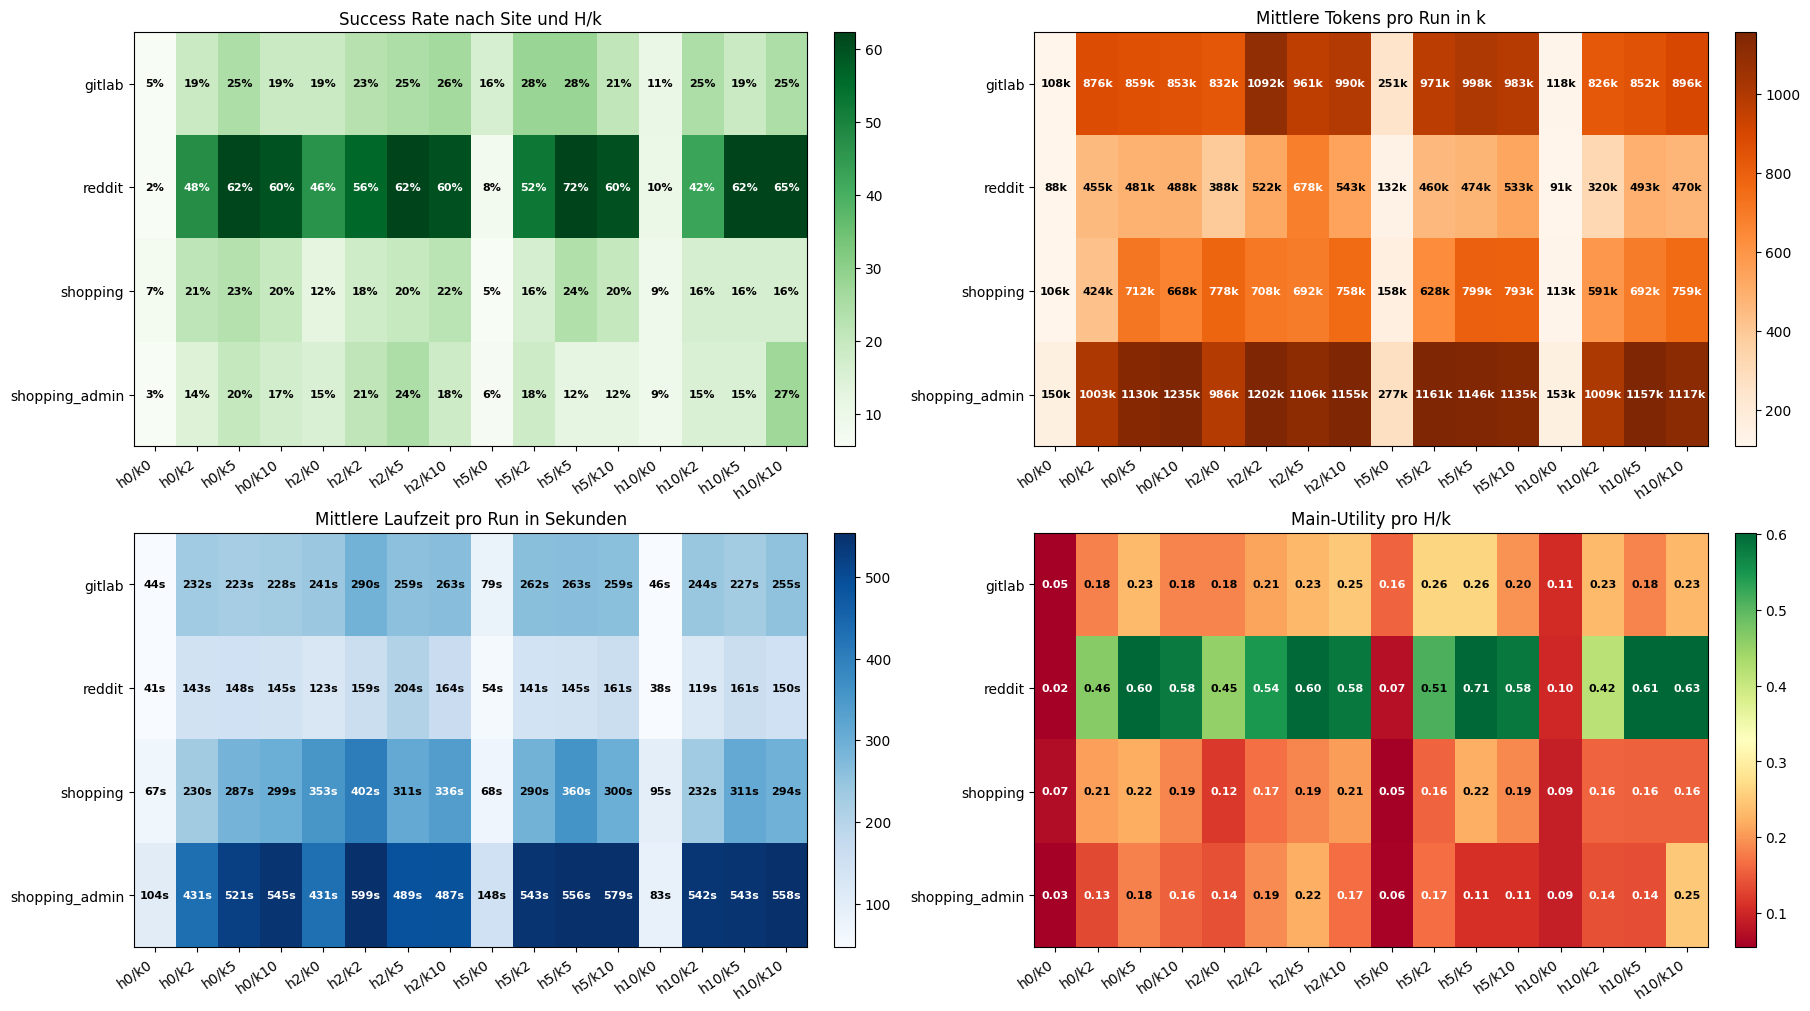

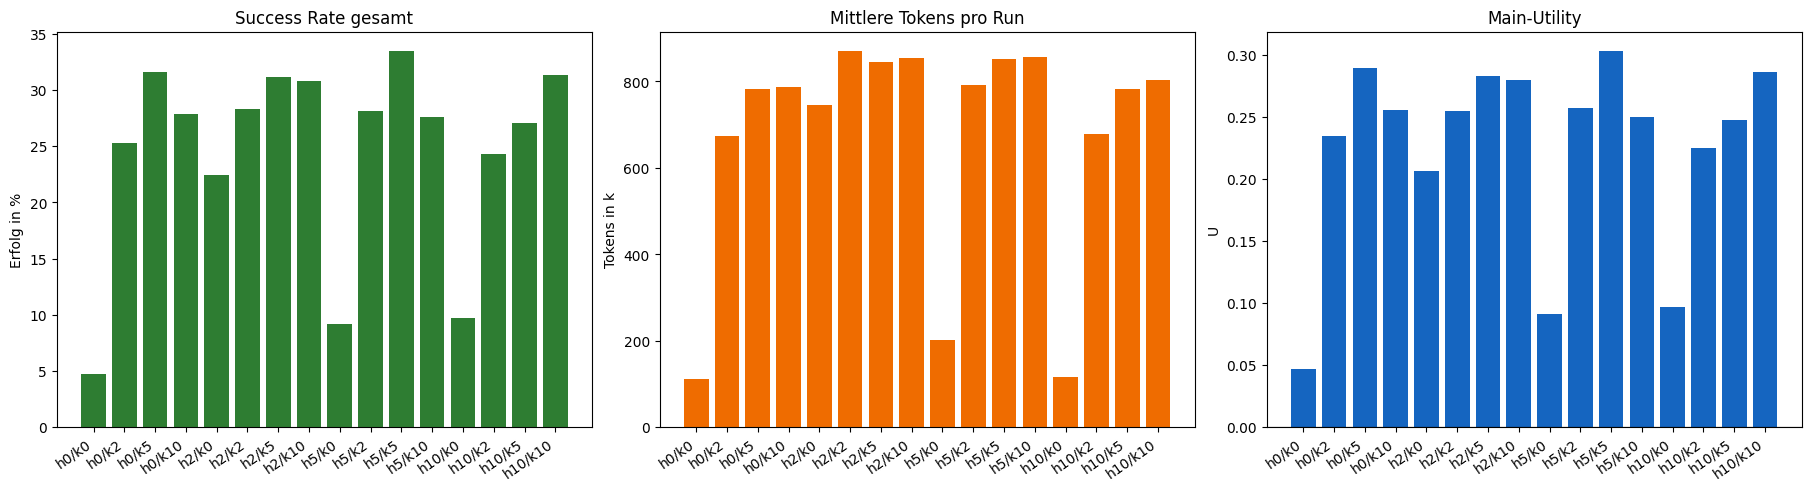

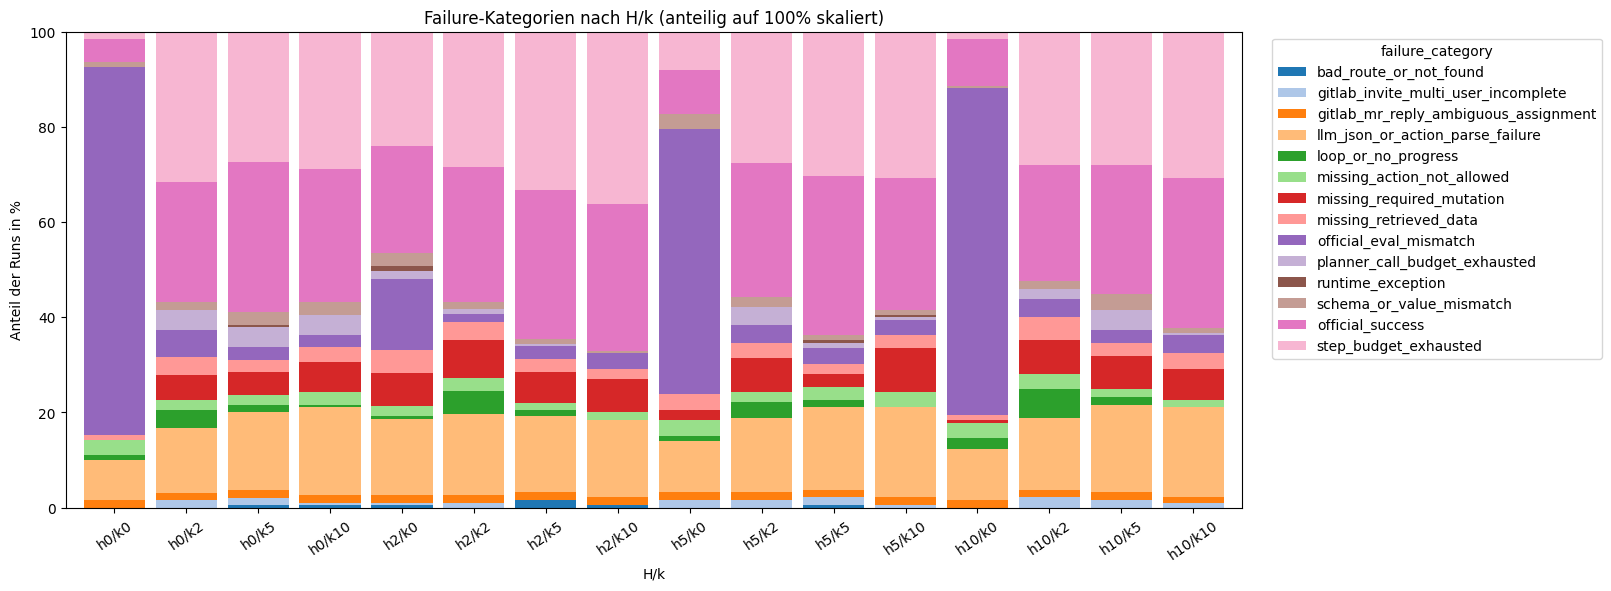

**Failure-Kategorien nach H/k: Prozentanteile und Basis (`total_runs`)**

failure_category,total_runs,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,runtime_exception,schema_or_value_mismatch,official_success,step_budget_exhausted
hk,,,,,,,,,,,,,,,
h0/k0,190,0.0%,0.0%,1.6%,8.4%,1.1%,3.2%,0.0%,1.1%,77.4%,0.0%,0.0%,1.1%,4.7%,1.6%
h0/k2,190,0.0%,1.6%,1.6%,13.7%,3.7%,2.1%,5.3%,3.7%,5.8%,4.2%,0.0%,1.6%,25.3%,31.6%
h0/k5,190,0.5%,1.6%,1.6%,16.3%,1.6%,2.1%,4.7%,2.6%,2.6%,4.2%,0.5%,2.6%,31.6%,27.4%
h0/k10,190,0.5%,0.5%,1.6%,18.4%,0.5%,2.6%,6.3%,3.2%,2.6%,4.2%,0.0%,2.6%,27.9%,28.9%
h2/k0,187,0.5%,0.5%,1.6%,16.0%,0.5%,2.1%,7.0%,4.8%,15.0%,1.6%,1.1%,2.7%,22.5%,24.1%
h2/k2,187,0.0%,1.1%,1.6%,17.1%,4.8%,2.7%,8.0%,3.7%,1.6%,1.1%,0.0%,1.6%,28.3%,28.3%
h2/k5,186,1.6%,0.0%,1.6%,16.1%,1.1%,1.6%,6.5%,2.7%,2.7%,0.5%,0.0%,1.1%,31.2%,33.3%
h2/k10,185,0.5%,0.0%,1.6%,16.2%,0.0%,1.6%,7.0%,2.2%,3.2%,0.0%,0.0%,0.5%,30.8%,36.2%
h5/k0,185,0.0%,1.6%,1.6%,10.8%,1.1%,3.2%,2.2%,3.2%,55.7%,0.0%,0.0%,3.2%,9.2%,8.1%


In [52]:
def pivot_site_hk(hk_df, metric):
    table = hk_df.pivot_table(index="site", columns="hk", values=metric, aggfunc="mean")
    site_index = [site for site in SITE_ORDER if site in table.index] + sorted([site for site in table.index if site not in SITE_ORDER])
    return table.reindex(index=site_index, columns=hk_order)


def show_figure(fig):
    display(fig)
    if plt is not None:
        plt.close(fig)


def _robust_limits(values):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return None, None
    vmin, vmax = np.nanpercentile(finite, [5, 95])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        vmin, vmax = np.nanmin(finite), np.nanmax(finite)
    if np.isclose(vmin, vmax):
        return None, None
    return vmin, vmax


def _text_color_for_background(im, value):
    if not np.isfinite(value):
        return "black"
    rgba = im.cmap(im.norm(value))
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "black" if luminance > 0.58 else "white"


def plot_heatmap(ax, data, title, fmt="{:.2f}", cmap="viridis", suffix=""):
    values = data.to_numpy(dtype=float)
    vmin, vmax = _robust_limits(values)
    im = ax.imshow(values, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if np.isfinite(values[i, j]):
                ax.text(
                    j,
                    i,
                    fmt.format(values[i, j]) + suffix,
                    ha="center",
                    va="center",
                    color=_text_color_for_background(im, values[i, j]),
                    fontsize=8,
                    fontweight="bold",
                )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def build_failure_color_map(frame):
    if "failure_category" not in frame.columns:
        return [], {}
    categories = sorted(frame["failure_category"].fillna("unknown").astype(str).unique().tolist())
    preferred_last = ["official_success", "step_budget_exhausted"]
    categories = [cat for cat in categories if cat not in preferred_last] + [cat for cat in preferred_last if cat in categories]
    cmap = plt.get_cmap("tab20") if plt is not None else None
    colors = {}
    for idx, category in enumerate(categories):
        colors[category] = cmap(idx % 20) if cmap is not None else None
    return categories, colors


FAILURE_CATEGORY_ORDER, FAILURE_CATEGORY_COLORS = build_failure_color_map(eval_df)


def failure_percent_by_hk(frame):
    failure_plot_df = frame.copy()
    failure_plot_df["failure_category"] = failure_plot_df["failure_category"].fillna("unknown").astype(str)
    failure_plot_df["hk"] = "h" + failure_plot_df["h"].astype(int).astype(str) + "/k" + failure_plot_df["k"].astype(int).astype(str)
    counts = (
        failure_plot_df.groupby(["hk", "failure_category"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reindex(index=[label for label in hk_order if label in failure_plot_df["hk"].unique()], fill_value=0)
        .reindex(columns=FAILURE_CATEGORY_ORDER, fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).mul(100).fillna(0)
    return counts, pct


def color_percent_columns(data, columns, cmap_name="YlOrRd"):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    available = [col for col in columns if col in data.columns]
    if not available:
        return styles
    values = data[available].apply(pd.to_numeric, errors="coerce")
    flat = values.to_numpy(dtype=float)
    finite = flat[np.isfinite(flat)]
    if finite.size == 0:
        return styles
    vmin, vmax = np.nanpercentile(finite, [5, 95])
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        vmin, vmax = np.nanmin(finite), np.nanmax(finite)
    for col in available:
        col_values = pd.to_numeric(data[col], errors="coerce")
        if np.isclose(vmin, vmax):
            norm = pd.Series(0.5, index=col_values.index)
        else:
            norm = ((col_values - vmin) / (vmax - vmin)).clip(0, 1)
        styles[col] = norm.map(lambda value: _cell_color_style(cmap_name, value) if np.isfinite(value) else "")
    return styles


def display_failure_percent_table(title, counts, pct):
    table = pct.copy()
    table.insert(0, "total_runs", counts.sum(axis=1))
    display(Markdown(title))
    display(
        table.style
        .format({"total_runs": "{:.0f}", **{col: "{:.1f}%" for col in pct.columns}})
        .apply(lambda data: color_percent_columns(data, list(pct.columns), cmap_name="YlOrRd"), axis=None)
    )


def plot_failure_percent_stack(pct, title, figsize=(16, 5.8)):
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    colors = [FAILURE_CATEGORY_COLORS.get(col) for col in pct.columns]
    pct.plot(kind="bar", stacked=True, ax=ax, width=0.85, color=colors)
    ax.set_title(title)
    ax.set_xlabel("H/k")
    ax.set_ylabel("Anteil der Runs in %")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="failure_category", bbox_to_anchor=(1.02, 1), loc="upper left")
    show_figure(fig)


if plt is not None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
    plot_heatmap(axes[0, 0], pivot_site_hk(hk_by_site, "success_rate") * 100, "Success Rate nach Site und H/k", fmt="{:.0f}", cmap="Greens", suffix="%")
    plot_heatmap(axes[0, 1], pivot_site_hk(hk_by_site, "avg_tokens_k"), "Mittlere Tokens pro Run in k", fmt="{:.0f}", cmap="Oranges", suffix="k")
    plot_heatmap(axes[1, 0], pivot_site_hk(hk_by_site, "avg_runtime_s"), "Mittlere Laufzeit pro Run in Sekunden", fmt="{:.0f}", cmap="Blues", suffix="s")
    plot_heatmap(axes[1, 1], pivot_site_hk(hk_by_site, "U_main_accuracy_first"), "Main-Utility pro H/k", fmt="{:.2f}", cmap="RdYlGn")
    show_figure(fig)

    by_hk = hk_global.sort_values(["h", "k"]).copy()
    x = np.arange(len(by_hk))
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
    axes[0].bar(x, by_hk["success_rate"] * 100, color="#2e7d32")
    axes[0].set_title("Success Rate gesamt")
    axes[0].set_ylabel("Erfolg in %")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(by_hk["hk"], rotation=35, ha="right")

    axes[1].bar(x, by_hk["avg_tokens_k"], color="#ef6c00")
    axes[1].set_title("Mittlere Tokens pro Run")
    axes[1].set_ylabel("Tokens in k")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(by_hk["hk"], rotation=35, ha="right")

    axes[2].bar(x, by_hk["U_main_accuracy_first"], color="#1565c0")
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set_title("Main-Utility")
    axes[2].set_ylabel("U")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(by_hk["hk"], rotation=35, ha="right")
    show_figure(fig)

    if "failure_category" in eval_df.columns:
        failure_counts, failure_pct = failure_percent_by_hk(eval_df)
        plot_failure_percent_stack(failure_pct, "Failure-Kategorien nach H/k (anteilig auf 100% skaliert)")
        display_failure_percent_table("**Failure-Kategorien nach H/k: Prozentanteile und Basis (`total_runs`)**", failure_counts, failure_pct)
else:
    display(Markdown("Matplotlib ist nicht verfuegbar; Grafiken werden uebersprungen."))


## 5. Site-spezifische Grafiken und h2/k2-Detailanalyse

Die globalen Grafiken werden hier je Site wiederholt. Dadurch sieht man, ob sich die H/k-Profile und die Failure-Verteilung innerhalb von `gitlab`, `reddit`, `shopping` und `shopping_admin` unterscheiden. Die Failure-Kategorien sind jeweils auf 100% pro H/k skaliert, damit die Zusammensetzung vergleichbar bleibt, auch wenn die absolute Run-Anzahl variiert.

Am Ende folgt eine Detailanalyse für `h2/k2`, weil diese Kombination als naheliegender PlanAct-Kandidat besonders interpretierbar ist.

### gitlab

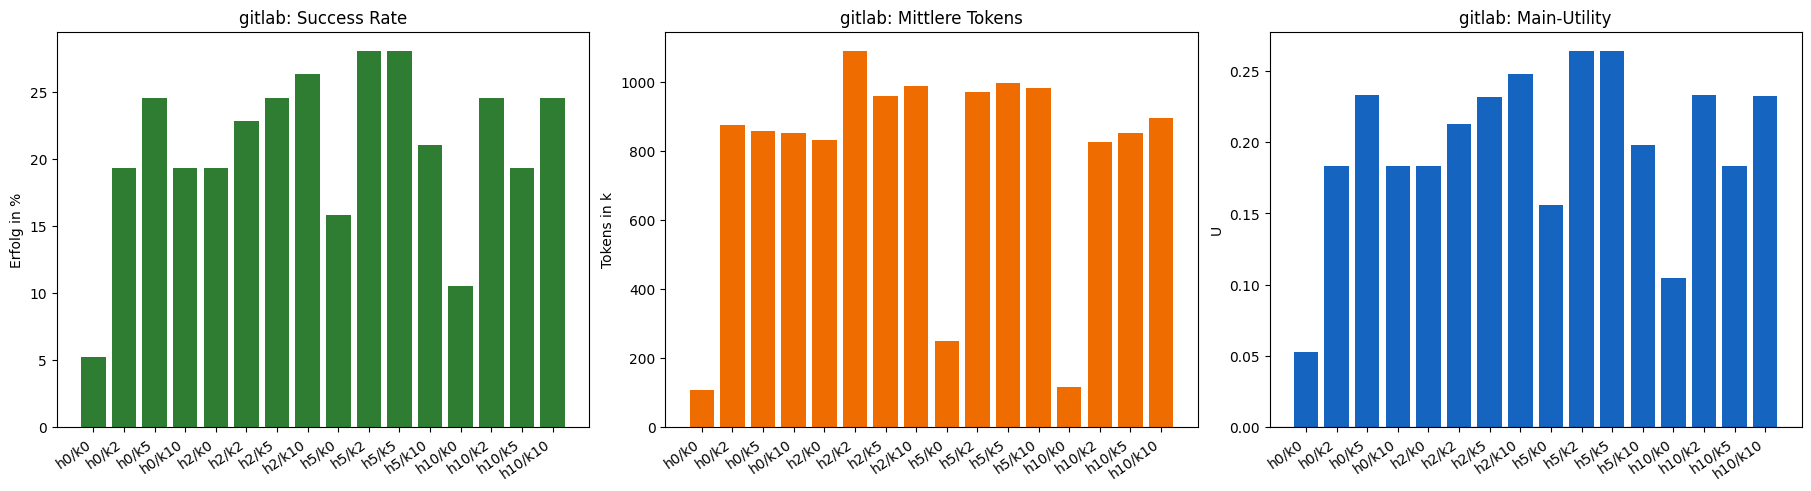

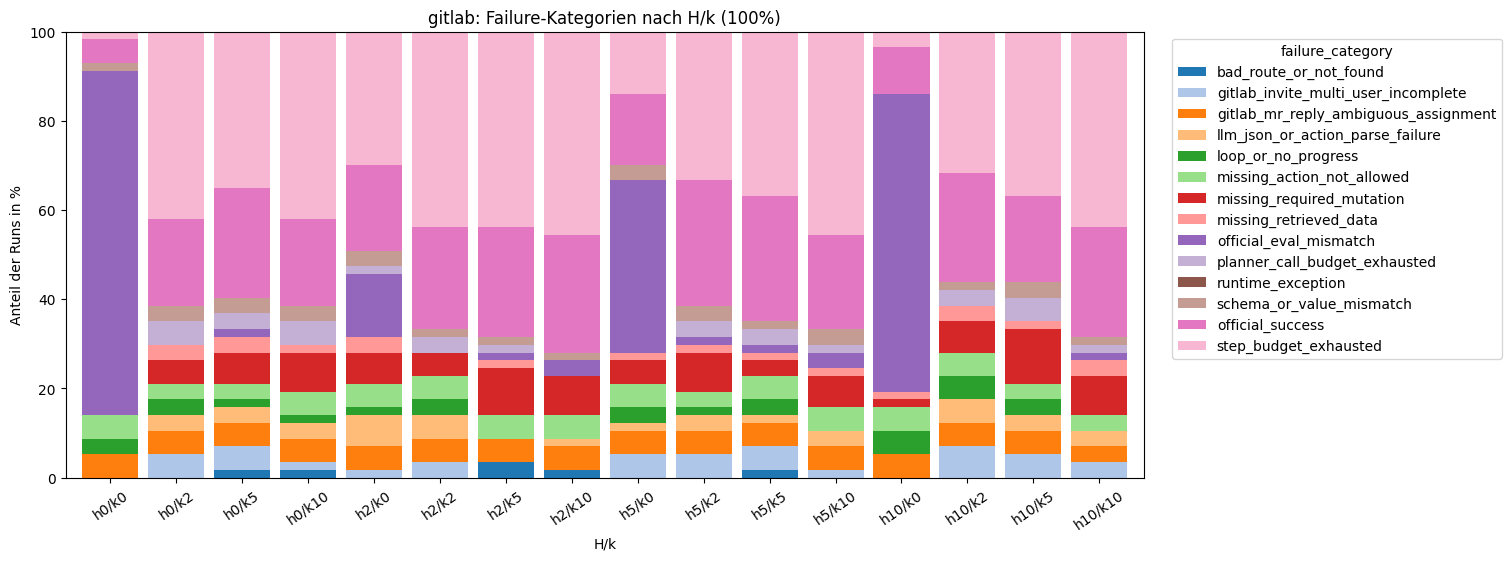

**gitlab: Failure-Kategorien nach H/k, Prozentanteile und total_runs**

failure_category,total_runs,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,runtime_exception,schema_or_value_mismatch,official_success,step_budget_exhausted
hk,,,,,,,,,,,,,,,
h0/k0,57,0.0%,0.0%,5.3%,0.0%,3.5%,5.3%,0.0%,0.0%,77.2%,0.0%,0.0%,1.8%,5.3%,1.8%
h0/k2,57,0.0%,5.3%,5.3%,3.5%,3.5%,3.5%,5.3%,3.5%,0.0%,5.3%,0.0%,3.5%,19.3%,42.1%
h0/k5,57,1.8%,5.3%,5.3%,3.5%,1.8%,3.5%,7.0%,3.5%,1.8%,3.5%,0.0%,3.5%,24.6%,35.1%
h0/k10,57,1.8%,1.8%,5.3%,3.5%,1.8%,5.3%,8.8%,1.8%,0.0%,5.3%,0.0%,3.5%,19.3%,42.1%
h2/k0,57,0.0%,1.8%,5.3%,7.0%,1.8%,5.3%,7.0%,3.5%,14.0%,1.8%,0.0%,3.5%,19.3%,29.8%
h2/k2,57,0.0%,3.5%,5.3%,5.3%,3.5%,5.3%,5.3%,0.0%,0.0%,3.5%,0.0%,1.8%,22.8%,43.9%
h2/k5,57,3.5%,0.0%,5.3%,0.0%,0.0%,5.3%,10.5%,1.8%,1.8%,1.8%,0.0%,1.8%,24.6%,43.9%
h2/k10,57,1.8%,0.0%,5.3%,1.8%,0.0%,5.3%,8.8%,0.0%,3.5%,0.0%,0.0%,1.8%,26.3%,45.6%
h5/k0,57,0.0%,5.3%,5.3%,1.8%,3.5%,5.3%,5.3%,1.8%,38.6%,0.0%,0.0%,3.5%,15.8%,14.0%


### reddit

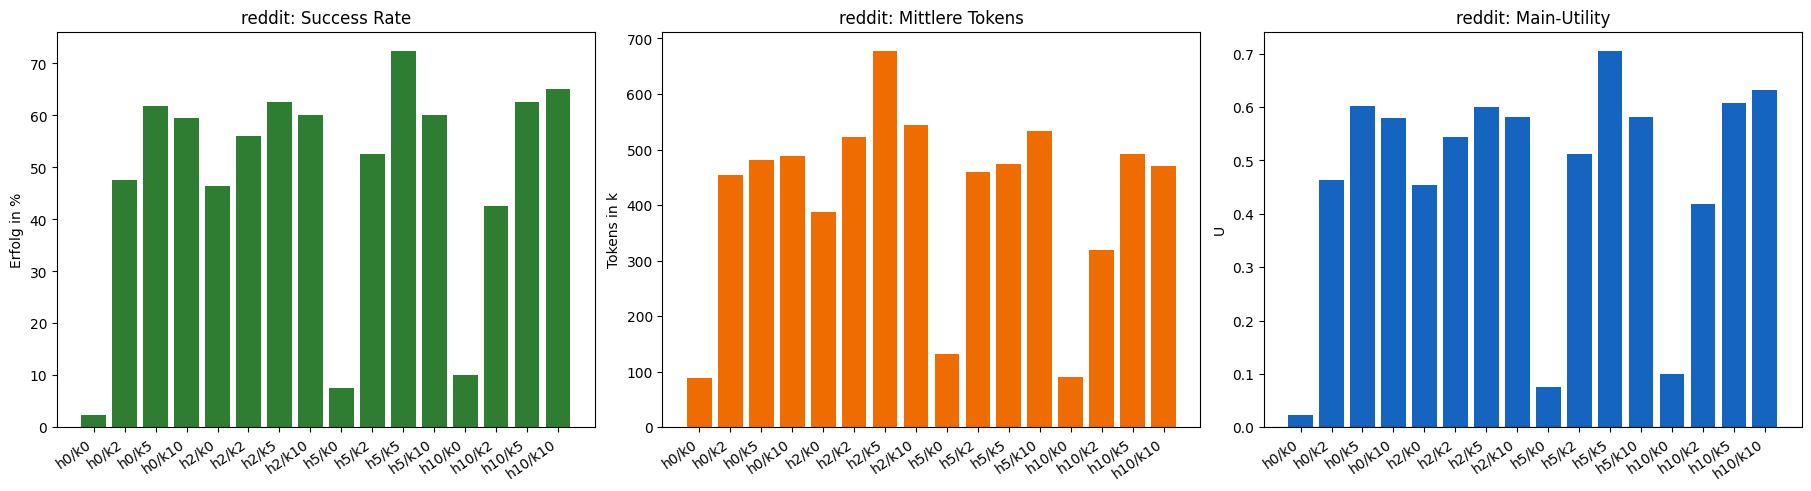

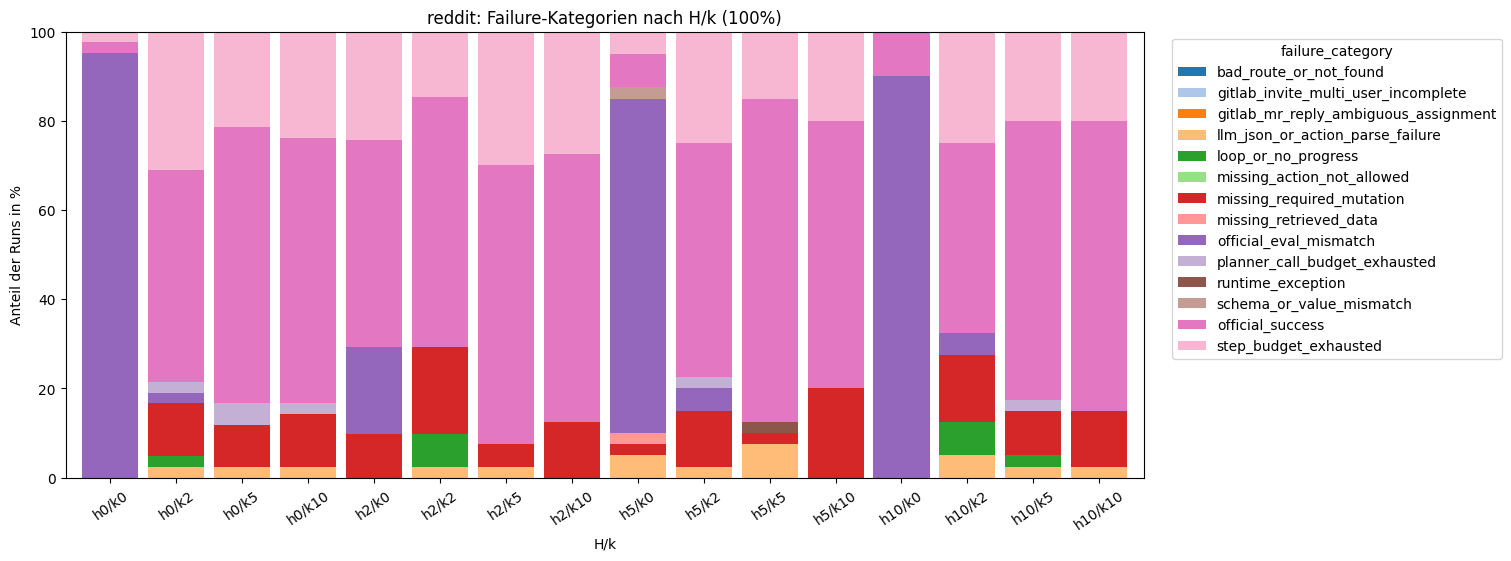

**reddit: Failure-Kategorien nach H/k, Prozentanteile und total_runs**

failure_category,total_runs,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,runtime_exception,schema_or_value_mismatch,official_success,step_budget_exhausted
hk,,,,,,,,,,,,,,,
h0/k0,42,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,95.2%,0.0%,0.0%,0.0%,2.4%,2.4%
h0/k2,42,0.0%,0.0%,0.0%,2.4%,2.4%,0.0%,11.9%,0.0%,2.4%,2.4%,0.0%,0.0%,47.6%,31.0%
h0/k5,42,0.0%,0.0%,0.0%,2.4%,0.0%,0.0%,9.5%,0.0%,0.0%,4.8%,0.0%,0.0%,61.9%,21.4%
h0/k10,42,0.0%,0.0%,0.0%,2.4%,0.0%,0.0%,11.9%,0.0%,0.0%,2.4%,0.0%,0.0%,59.5%,23.8%
h2/k0,41,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,9.8%,0.0%,19.5%,0.0%,0.0%,0.0%,46.3%,24.4%
h2/k2,41,0.0%,0.0%,0.0%,2.4%,7.3%,0.0%,19.5%,0.0%,0.0%,0.0%,0.0%,0.0%,56.1%,14.6%
h2/k5,40,0.0%,0.0%,0.0%,2.5%,0.0%,0.0%,5.0%,0.0%,0.0%,0.0%,0.0%,0.0%,62.5%,30.0%
h2/k10,40,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,12.5%,0.0%,0.0%,0.0%,0.0%,0.0%,60.0%,27.5%
h5/k0,40,0.0%,0.0%,0.0%,5.0%,0.0%,0.0%,2.5%,2.5%,75.0%,0.0%,0.0%,2.5%,7.5%,5.0%


### shopping

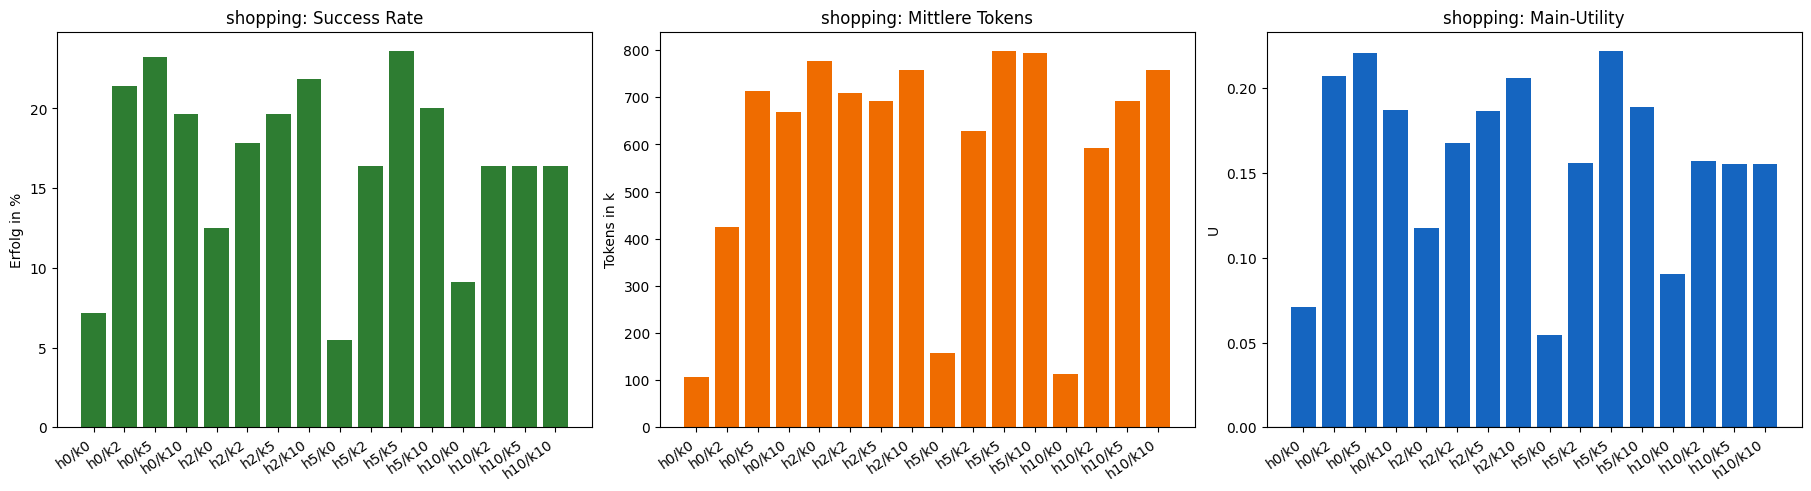

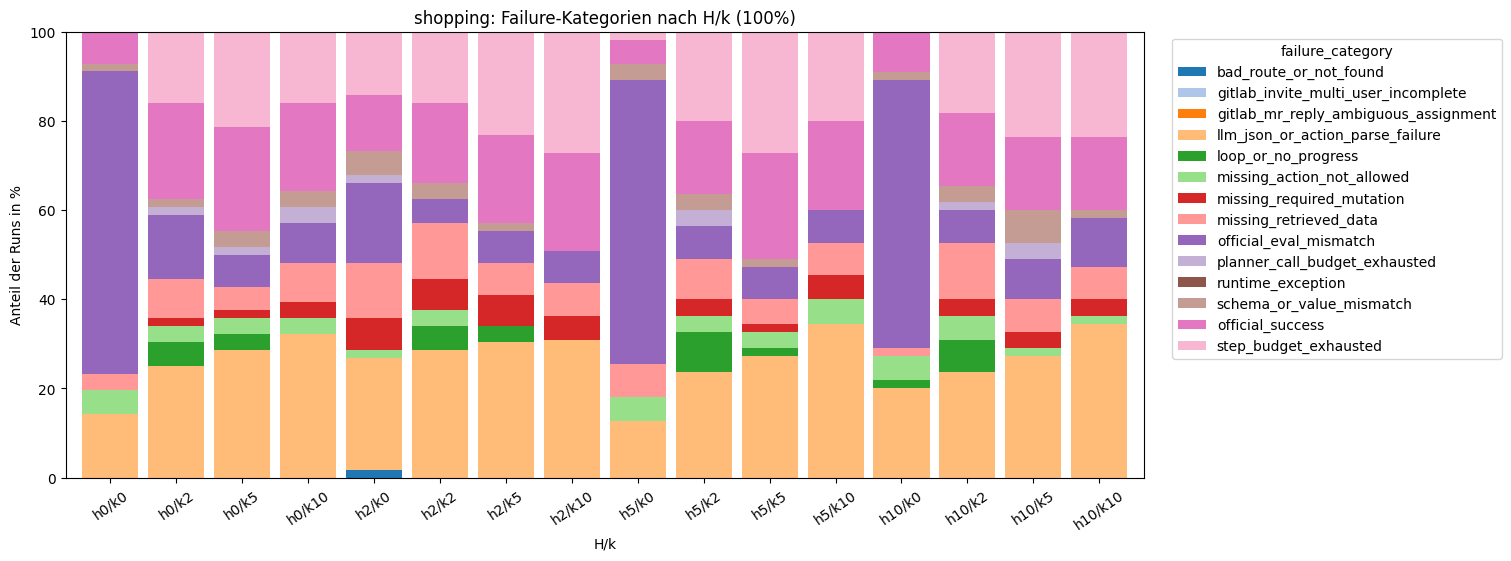

**shopping: Failure-Kategorien nach H/k, Prozentanteile und total_runs**

failure_category,total_runs,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,runtime_exception,schema_or_value_mismatch,official_success,step_budget_exhausted
hk,,,,,,,,,,,,,,,
h0/k0,56,0.0%,0.0%,0.0%,14.3%,0.0%,5.4%,0.0%,3.6%,67.9%,0.0%,0.0%,1.8%,7.1%,0.0%
h0/k2,56,0.0%,0.0%,0.0%,25.0%,5.4%,3.6%,1.8%,8.9%,14.3%,1.8%,0.0%,1.8%,21.4%,16.1%
h0/k5,56,0.0%,0.0%,0.0%,28.6%,3.6%,3.6%,1.8%,5.4%,7.1%,1.8%,0.0%,3.6%,23.2%,21.4%
h0/k10,56,0.0%,0.0%,0.0%,32.1%,0.0%,3.6%,3.6%,8.9%,8.9%,3.6%,0.0%,3.6%,19.6%,16.1%
h2/k0,56,1.8%,0.0%,0.0%,25.0%,0.0%,1.8%,7.1%,12.5%,17.9%,1.8%,0.0%,5.4%,12.5%,14.3%
h2/k2,56,0.0%,0.0%,0.0%,28.6%,5.4%,3.6%,7.1%,12.5%,5.4%,0.0%,0.0%,3.6%,17.9%,16.1%
h2/k5,56,0.0%,0.0%,0.0%,30.4%,3.6%,0.0%,7.1%,7.1%,7.1%,0.0%,0.0%,1.8%,19.6%,23.2%
h2/k10,55,0.0%,0.0%,0.0%,30.9%,0.0%,0.0%,5.5%,7.3%,7.3%,0.0%,0.0%,0.0%,21.8%,27.3%
h5/k0,55,0.0%,0.0%,0.0%,12.7%,0.0%,5.5%,0.0%,7.3%,63.6%,0.0%,0.0%,3.6%,5.5%,1.8%


### shopping_admin

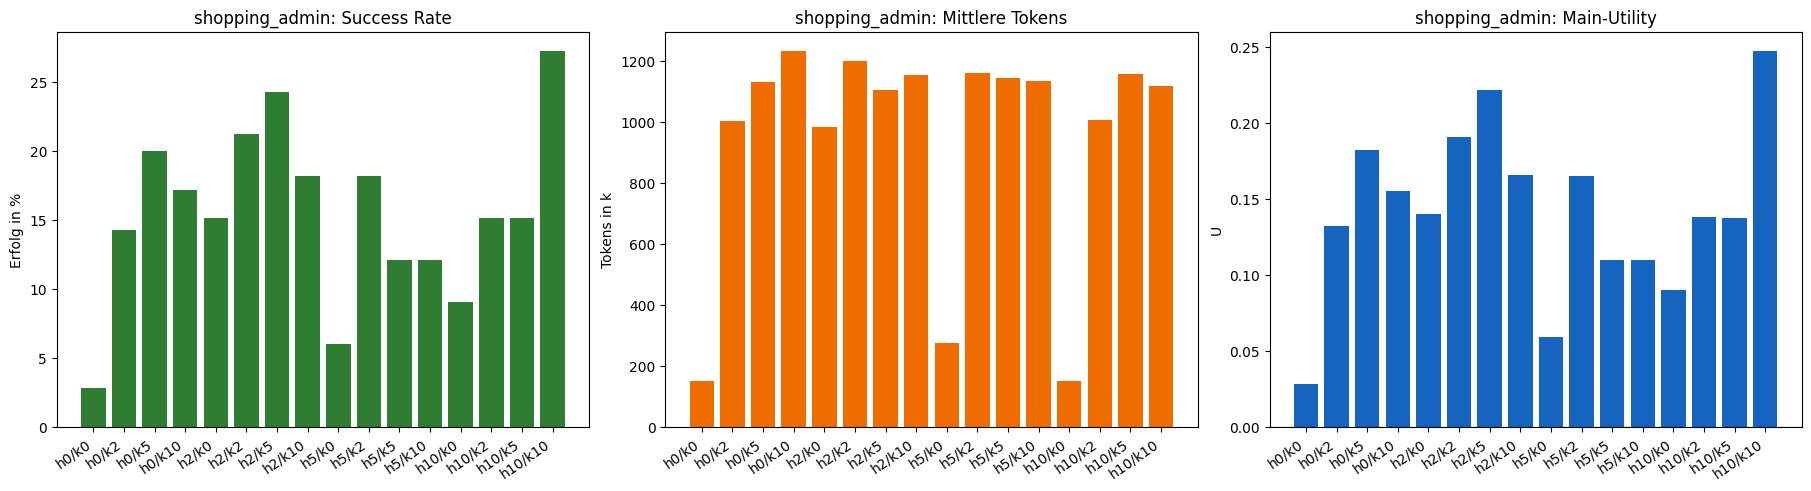

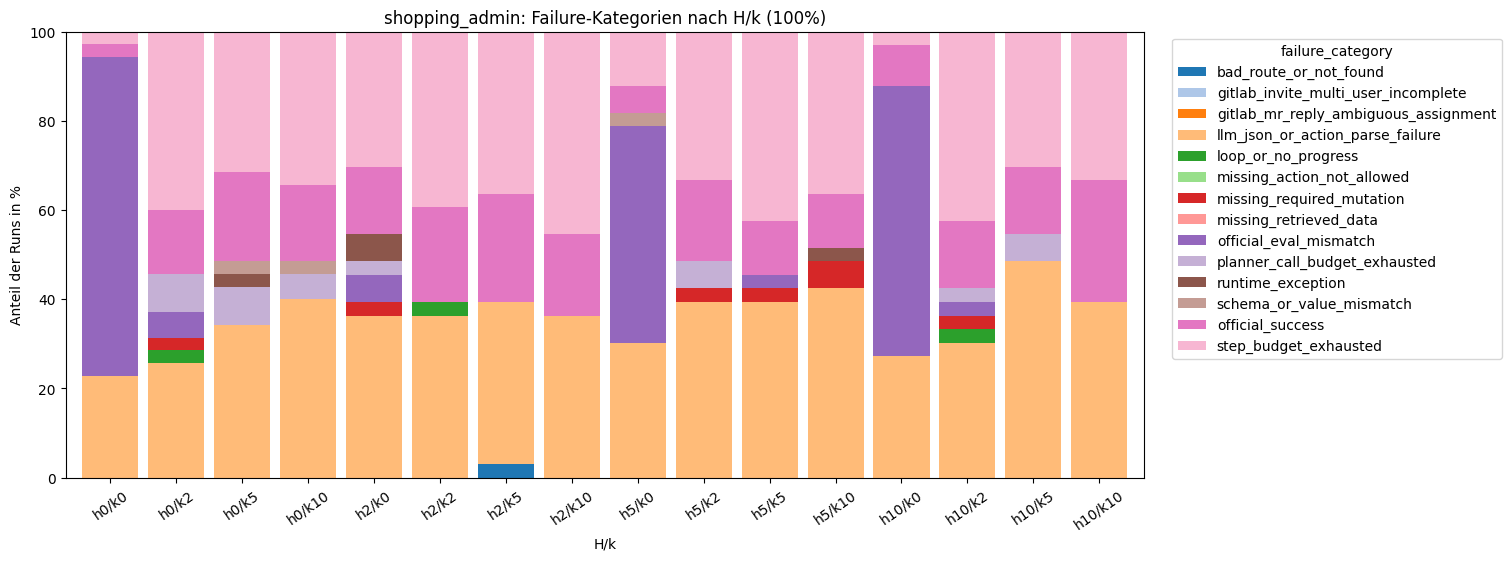

**shopping_admin: Failure-Kategorien nach H/k, Prozentanteile und total_runs**

failure_category,total_runs,bad_route_or_not_found,gitlab_invite_multi_user_incomplete,gitlab_mr_reply_ambiguous_assignment,llm_json_or_action_parse_failure,loop_or_no_progress,missing_action_not_allowed,missing_required_mutation,missing_retrieved_data,official_eval_mismatch,planner_call_budget_exhausted,runtime_exception,schema_or_value_mismatch,official_success,step_budget_exhausted
hk,,,,,,,,,,,,,,,
h0/k0,35,0.0%,0.0%,0.0%,22.9%,0.0%,0.0%,0.0%,0.0%,71.4%,0.0%,0.0%,0.0%,2.9%,2.9%
h0/k2,35,0.0%,0.0%,0.0%,25.7%,2.9%,0.0%,2.9%,0.0%,5.7%,8.6%,0.0%,0.0%,14.3%,40.0%
h0/k5,35,0.0%,0.0%,0.0%,34.3%,0.0%,0.0%,0.0%,0.0%,0.0%,8.6%,2.9%,2.9%,20.0%,31.4%
h0/k10,35,0.0%,0.0%,0.0%,40.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.7%,0.0%,2.9%,17.1%,34.3%
h2/k0,33,0.0%,0.0%,0.0%,36.4%,0.0%,0.0%,3.0%,0.0%,6.1%,3.0%,6.1%,0.0%,15.2%,30.3%
h2/k2,33,0.0%,0.0%,0.0%,36.4%,3.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,21.2%,39.4%
h2/k5,33,3.0%,0.0%,0.0%,36.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,24.2%,36.4%
h2/k10,33,0.0%,0.0%,0.0%,36.4%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,18.2%,45.5%
h5/k0,33,0.0%,0.0%,0.0%,30.3%,0.0%,0.0%,0.0%,0.0%,48.5%,0.0%,0.0%,3.0%,6.1%,12.1%


### h2/k2 Detailanalyse

**134 Fehlschlaege von 187 Runs.**

,task_id,site,task_type,task_capability,failure_category,total_steps,total_tokens,runtime_s,runtime_invalid_actions,runtime_loop_events,num_step_errors,last_step_error,output_dir
53,522,gitlab,MUTATE,mutate_gitlab_fork,llm_json_or_action_parse_failure,90.0,2441854.0,846.159,32.0,39.0,30.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
69,800,gitlab,MUTATE,mutate_gitlab_group,planner_call_budget_exhausted,80.0,3128271.0,805.082,37.0,49.0,28.0,Action repeats a recent no-progress action; ch...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
85,444,gitlab,MUTATE,mutate_gitlab_file_edit,planner_call_budget_exhausted,77.0,2465557.0,802.266,51.0,41.0,42.0,UI action target looks like a selector or visi...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
117,644,reddit,MUTATE,mutate_forum_post,loop_or_no_progress,6.0,167058.0,45.060,0.0,0.0,0.0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
149,505,shopping_admin,MUTATE,mutate_admin_stock,step_budget_exhausted,15.0,572514.0,783.676,4.0,1.0,2.0,timed out,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2858,778,shopping_admin,NAVIGATE,navigate_generic,step_budget_exhausted,50.0,1787601.0,828.796,0.0,6.0,0.0,NaN,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2874,780,shopping_admin,NAVIGATE,navigate_generic,llm_json_or_action_parse_failure,50.0,718385.0,612.617,33.0,33.0,33.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2890,782,shopping_admin,NAVIGATE,navigate_generic,llm_json_or_action_parse_failure,50.0,349957.0,319.392,38.0,29.0,38.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...
2938,707,shopping_admin,NAVIGATE,navigate_admin_sales_report_filter,llm_json_or_action_parse_failure,14.0,264154.0,239.462,4.0,6.0,4.0,Executor response did not contain a usable JSO...,/Users/niclascramer/Privat/Uni/Uni-Reutlingen/...


,failure_category,h2k2_count
0,step_budget_exhausted,53
1,llm_json_or_action_parse_failure,32
2,missing_required_mutation,15
3,loop_or_no_progress,9
4,missing_retrieved_data,7
5,missing_action_not_allowed,5
6,gitlab_mr_reply_ambiguous_assignment,3
7,schema_or_value_mismatch,3
8,official_eval_mismatch,3
9,planner_call_budget_exhausted,2


**Automatische Hinweise fuer bessere h2/k2-Laeufe**

- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.
- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.
- MUTATE-Finalisierung weiter verbessern: vor `SUCCESS` sollte ein sichtbarer Zustand nach der letzten Mutation nochmals aktiv validiert werden.
- Runtime-Replanning staerker machen: bei wiederholtem gleichen URL-/Action-Muster frueher neuen Subgoal verlangen statt weiter im Loop zu bleiben.
- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.

In [53]:
def plot_site_bars_and_failures(site):
    if plt is None:
        return None
    site_hk = hk_by_site[hk_by_site["site"].eq(site)].sort_values(["h", "k"]).copy()
    site_eval = eval_df[eval_df["site"].eq(site)].copy()
    if site_hk.empty:
        return None

    x = np.arange(len(site_hk))
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), constrained_layout=True)
    axes[0].bar(x, site_hk["success_rate"] * 100, color="#2e7d32")
    axes[0].set_title(f"{site}: Success Rate")
    axes[0].set_ylabel("Erfolg in %")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(site_hk["hk"], rotation=35, ha="right")

    axes[1].bar(x, site_hk["avg_tokens_k"], color="#ef6c00")
    axes[1].set_title(f"{site}: Mittlere Tokens")
    axes[1].set_ylabel("Tokens in k")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(site_hk["hk"], rotation=35, ha="right")

    axes[2].bar(x, site_hk["U_main_accuracy_first"], color="#1565c0")
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set_title(f"{site}: Main-Utility")
    axes[2].set_ylabel("U")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(site_hk["hk"], rotation=35, ha="right")
    show_figure(fig)

    if "failure_category" in site_eval.columns and not site_eval.empty:
        counts, pct = failure_percent_by_hk(site_eval)
        plot_failure_percent_stack(pct, f"{site}: Failure-Kategorien nach H/k (100%)", figsize=(15, 5.5))
        display_failure_percent_table(f"**{site}: Failure-Kategorien nach H/k, Prozentanteile und total_runs**", counts, pct)


for site in [s for s in SITE_ORDER if s in eval_df["site"].unique()] + sorted([s for s in eval_df["site"].unique() if s not in SITE_ORDER]):
    display(Markdown(f"### {site}"))
    plot_site_bars_and_failures(site)

# Detailblick: Was verhindert h2/k2 noch?
h2k2_all = eval_df[(eval_df["h"].eq(2)) & (eval_df["k"].eq(2))].copy()
h2k2_failures = h2k2_all[h2k2_all["success"].eq(0)].copy()
display(Markdown(f"### h2/k2 Detailanalyse\n\n**{len(h2k2_failures)} Fehlschlaege von {len(h2k2_all)} Runs.**"))
if not h2k2_failures.empty:
    detail_cols = [
        "task_id", "site", "task_type", "task_capability", "failure_category",
        "total_steps", "total_tokens", "runtime_s", "runtime_invalid_actions",
        "runtime_loop_events", "num_step_errors", "last_step_error", "output_dir",
    ]
    display(h2k2_failures[[c for c in detail_cols if c in h2k2_failures.columns]])
    display(h2k2_failures["failure_category"].fillna("unknown").value_counts().rename_axis("failure_category").reset_index(name="h2k2_count"))

    recommendations = []
    failure_text = h2k2_failures["failure_category"].astype(str)
    if failure_text.str.contains("llm_json_or_action_parse_failure", na=False).any():
        recommendations.append("- Executor-Prompt/Candidate-Auswahl weiter schaerfen: mehrere h2/k2-Fehler entstehen, weil das Modell sichtbare Labels, Selektoren oder nicht aktuelle `bid`s nutzt.")
    if failure_text.str.contains("step_budget_exhausted", na=False).any():
        recommendations.append("- Fuer Shopping-/MUTATE-Runs koennte `--max-steps` testweise von 15 auf 20 oder 25 steigen; h2/k2 plant besser, braucht aber oft mehr Schritte.")
    if failure_text.str.contains("missing_required_mutation", na=False).any():
        recommendations.append("- MUTATE-Finalisierung weiter verbessern: vor `SUCCESS` sollte ein sichtbarer Zustand nach der letzten Mutation nochmals aktiv validiert werden.")
    if failure_text.str.contains("loop_or_no_progress", na=False).any():
        recommendations.append("- Runtime-Replanning staerker machen: bei wiederholtem gleichen URL-/Action-Muster frueher neuen Subgoal verlangen statt weiter im Loop zu bleiben.")
    if h2k2_failures.get("runtime_invalid_actions", pd.Series(0, index=h2k2_failures.index)).fillna(0).sum() > 0:
        recommendations.append("- Grounding erweitern: mehr Kandidaten oder fokussierte Kandidaten fuer Formulare, Grid-Zeilen und Produktbuttons in den Prompt aufnehmen.")
    if not recommendations:
        recommendations.append("- Keine der Standard-Regeln hat angeschlagen; die h2/k2-Fehler sollten anhand von Trace, HAR und `output_dir` manuell gruppiert werden.")
    display(Markdown("**Automatische Hinweise fuer bessere h2/k2-Laeufe**\n\n" + "\n".join(recommendations)))
